

## Project Overview: Geospatial Intelligence in Agri-Logistics




### Introduction and Context
In the global agribusiness sector, **logistical efficiency** is the primary driver of profitability. Beyond mere transportation, the strategic placement of post-harvest infrastructure determines the resilience of the entire supply chain. By leveraging **Geographic Information Systems (GIS)**, we can analyze the spatial distribution of collection centers (silos) to minimize "farm-to-gate" latency and optimize transport overhead from harvest zones.

This project demonstrates an advanced workflow for the **visualization and spatial auditing** of a regional grain storage network.

### Problem Statement
A geographic imbalance between high-yield production zones and available storage capacity leads to critical systemic failures:

* **Operational Bottlenecks:** Reception delays during peak harvest windows.
* **Carbon Footprint Escalation:** Increased greenhouse gas emissions due to sub-optimal haulage distances.
* **Quantitative & Qualitative Loss:** Post-harvest spoilage resulting from infrastructure gaps and inadequate storage conditions.

### Technical Objectives
To address these challenges, this analysis implements three core geospatial techniques:

* **Proportional Symbolization:** Mapping storage capacity through graduated point markers to visualize volumetric data.
* **Multivariate Categorization:** Utilizing color-coded visual variables to differentiate between management models (State, Private, and Cooperative).
* **Spatial Density Analysis:** Implementing **Kernel Density Estimation (KDE)** via Heatmaps to identify infrastructure saturation zones and underserved agricultural frontiers.

### The Technology Stack
The solution is built on the **Python Data Science** ecosystem, ensuring a reproducible and scalable workflow:

| Library | Application |
| :--- | :--- |
| **Pandas & NumPy** | High-performance data manipulation and synthetic attribute generation. |
| **GeoPandas** | Spatial operations, coordinate reference system (CRS) management, and vector processing. |
| **Matplotlib** | Production of high-fidelity static cartography and thematic layers. |
| **Folium / Leaflet** | Deployment of web-based interactive dashboards for stakeholder engagement. |

---

## Data Selection and Synthetic Generation

To simulate a realistic regional grain storage network, we generate a synthetic dataset representing 100 strategic collection points. This approach allows us to model a variety of management structures and volumetric capacities within a defined agricultural frontier.

### Geographic Data Synthesis
We initialize the dataset with random spatial coordinates (localized within the Southern Cone, e.g., Argentina) and assign multivariate attributes to each infrastructure point.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

In [2]:
# Configuration: Define the number of silos for the regional model
n_silos = 100

# Attribute Generation: 
# - Capacity: Volumetric storage in Metric Tons (MT)
# - Management Type: Operational model classification
# - Spatial Coordinates: Lat/Lon within the target agricultural zone
data = {
    'id': range(n_silos),
    'capacity_mt': np.random.randint(5000, 50000, n_silos),
    'management_type': np.random.choice(['Private', 'Cooperative', 'State-Owned'], n_silos),
    'lat': np.random.uniform(-35, -30, n_silos),
    'lon': np.random.uniform(-62, -58, n_silos)
}

# DataFrame Construction
df = pd.DataFrame(data)

# Vectorization: Creating Point geometries from coordinates
geometry = [Point(xy) for xy in zip(df.lon, df.lat)]

# GeoDataFrame Initialization: Set initial CRS to WGS84 (Geographic)
silos_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Preview the first 5 records of the spatial collection
silos_gdf.head(5)

,id,capacity_mt,management_type,lat,lon,geometry
0,0,16037,State-Owned,-30.365582,-58.419992,POINT (-58.41999 -30.36558)
1,1,32329,Cooperative,-34.056057,-61.281620,POINT (-61.28162 -34.05606)
2,2,16063,State-Owned,-33.746383,-60.596644,POINT (-60.59664 -33.74638)
3,3,35461,Private,-34.176803,-61.656077,POINT (-61.65608 -34.1768)
4,4,34549,Private,-34.779757,-60.214923,POINT (-60.21492 -34.77976)


### Coordinate Reference System (CRS) Transformation
Standard geographic coordinates (WGS84) are ideal for global positioning but unsuitable for precise distance and area calculations. To enable metric-based spatial analysis, we re-project the dataset to a **Projected Coordinate System (UTM Zone 20S)**.

In [3]:
# Re-projection: Transforming to UTM (EPSG:32720) for metric-based calculations
silos_metric = silos_gdf.to_crs(epsg=32720)

## Effective Symbolization

To transform raw geographic data into actionable intelligence, we apply Multivariate Mapping techniques. This allows us to visualize two distinct variables simultaneously:

Volumetric Capacity (Quantitative): Represented through Proportional Symbols (Marker Size). Larger points indicate higher storage potential.

Management Model (Qualitative): Represented through Color Categorization (Hue). This differentiates the operational nature of each facility.

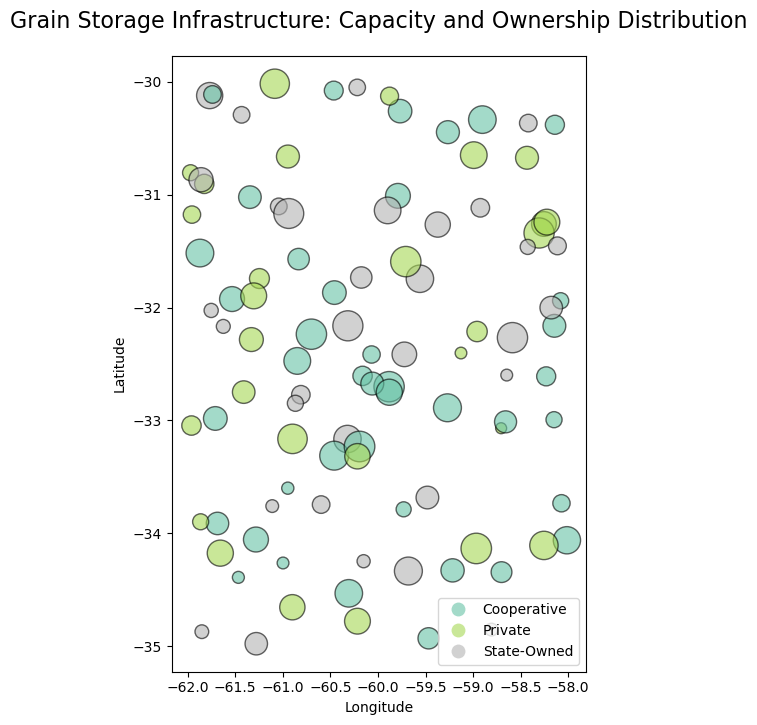

In [4]:
import matplotlib.pyplot as plt

# Initialize the figure with a professional aspect ratio
fig, ax = plt.subplots(figsize=(12, 8))

# Execute Multivariate Symbolization
silos_gdf.plot(
    ax=ax,
    # Variable 1: Proportional scaling (Capacity in Metric Tons)
    # Dividing by 100 normalizes the point size for optimal map legibility
    markersize=silos_gdf['capacity_mt'] / 100, 
    
    # Variable 2: Categorical classification (Management Model)
    column='management_type', 
    
    legend=True,
    alpha=0.6,
    edgecolor='black',
    cmap='Set2'
)

# Apply formal cartographic metadata
ax.set_title("Grain Storage Infrastructure: Capacity and Ownership Distribution", 
             fontsize=16, pad=20)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

## Density Visualization & Interactive Dashboard (Folium)

To finalize the analysis, we implement a Kernel Density Estimation (KDE) heatmap layered with an interactive vector layer. This dual-visualization approach allows stakeholders to identify regional infrastructure clusters (Heatmap) while maintaining access to granular, site-specific data (Interactive Markers).

In [5]:
import folium
from folium.plugins import HeatMap
from branca.element import Template, MacroElement

# 1. Initialize Base Map (CartoDB Positron for high-contrast visibility)
m = folium.Map(location=[-32.5, -60], zoom_start=7, tiles='CartoDB Positron')

# 2. Heatmap Layer (Weighted by Storage Capacity)
heat_data = [[row.geometry.y, row.geometry.x, row['capacity_mt']] for index, row in silos_gdf.iterrows()]
HeatMap(heat_data, radius=20, blur=15, name="Density Heatmap (Capacity)").add_to(m)

# 3. Color Dictionary (Strategic Contrast Palette)
color_hex = {'Private': '#000000', 'Cooperative': '#FFFFFF', 'State-Owned': '#FB5607'}

# 4. Interactive Layer Creation (Grouped by Management Type)
management_types = silos_gdf['management_type'].unique()
silo_groups = {t: folium.FeatureGroup(name=f"Silos: {t}").add_to(m) for t in management_types}

for index, row in silos_gdf.iterrows():
    color_silo = color_hex.get(row['management_type'], '#000000')
    
    # HTML template for Interactive Popups
    html_popup = f"""
    <div style='font-family: Arial; font-size: 12px; width: 160px;'>
        <h4 style='margin: 0 0 10px 0; color: {color_silo if color_silo != "#FFFFFF" else "#333"};'>Facility Specs</h4>
        <b>ID:</b> {row['id']}<br>
        <b>Type:</b> {row['management_type']}<br>
        <b>Capacity:</b> {row['capacity_mt']:,} MT<br>
        <hr style='margin: 8px 0;'>
        <small>Coord: {row.geometry.y:.4f}, {row.geometry.x:.4f}</small>
    </div>
    """
    
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color='black', 
        weight=1,
        fill=True,
        fill_color=color_silo,
        fill_opacity=0.9,
        popup=folium.Popup(html_popup, max_width=200),
        tooltip=f"Silo {row['id']} - Click for details"
    ).add_to(silo_groups[row['management_type']])

# 5. Dashboard Header
header_html = '<h3 align="center" style="font-size:18px; margin-top:10px; font-family: Arial;"><b>Agro-Industrial Storage Infrastructure Analysis</b></h3>'
m.get_root().html.add_child(folium.Element(header_html))

# 6. LEGEND WITH VISIBILITY CONTROL (JavaScript Logic)
legend_layer = folium.FeatureGroup(name="Toggle Legend Overlay", show=True).add_to(m)

legend_template = f"""
{{% macro html(this, kwargs) %}}
<div id='maplegend' class='maplegend' 
    style='position: fixed; z-index:9999; border:2px solid grey; background-color:rgba(255, 255, 255, 0.9);
     border-radius:6px; padding: 12px; font-size:12px; right: 15px; bottom: 15px; font-family: Arial; 
     box-shadow: 2px 2px 5px rgba(0,0,0,0.2); display: block;'>
     
    <div style='font-weight: bold; margin-bottom: 8px;'>Management Model</div>
    <ul style='list-style: none; padding: 0; margin: 0;'>
        <li style='margin-bottom: 5px;'><span style='background:{color_hex['Private']}; float:left; height:12px; width:12px; margin-right:8px; border-radius:50%; border:1px solid #333;'></span>Private</li>
        <li style='margin-bottom: 5px;'><span style='background:{color_hex['Cooperative']}; float:left; height:12px; width:12px; margin-right:8px; border-radius:50%; border:1px solid #333;'></span>Cooperative</li>
        <li style='margin-bottom: 10px;'><span style='background:{color_hex['State-Owned']}; float:left; height:12px; width:12px; margin-right:8px; border-radius:50%; border:1px solid #333;'></span>State-Owned</li>
    </ul>
    <div style='font-weight: bold; margin-bottom: 5px;'>Storage Density</div>
    <div style='background: linear-gradient(to right, blue, lime, orange, red); height: 10px; width: 80px; border: 1px solid #999; margin-bottom: 8px;'></div>
    <div style='font-size: 10px; color: #555; border-top: 1px solid #ccc; padding-top: 5px;'>
        Author: @alexisdaraujoc<br>CRS: EPSG:32720
    </div>
</div>

<script>
    function toggleLegend() {{
        var legend = document.getElementById('maplegend');
        var layerName = "Toggle Legend Overlay";
        
        {m.get_name()}.on('overlayadd', function(eventLayer) {{
            if (eventLayer.name === layerName) {{
                legend.style.display = 'block';
            }}
        }});
        {m.get_name()}.on('overlayremove', function(eventLayer) {{
            if (eventLayer.name === layerName) {{
                legend.style.display = 'none';
            }}
        }});
    }}
    setTimeout(toggleLegend, 500);
</script>
{{% endmacro %}}
"""

macro = MacroElement()
macro._template = Template(legend_template)
legend_layer.add_child(macro)

# 7. Final Layer Control Configuration
folium.LayerControl(collapsed=False).add_to(m)

# Save output for deployment
m.save("day1_points_silos.html")

# Display map in notebook
m

## Strategic Findings and Analytical Conclusions


### UX/UI & Cartographic Efficiency
Dynamic Information Layering: The implementation of a toggleable legend via custom JavaScript injection solves a core limitation in standard Folium builds. This allows stakeholders to minimize cognitive load by clearing the canvas for unobstructed visual analysis while maintaining access to technical metadata (CRS: EPSG:32720) on demand.

Visual Hierarchy: Utilizing high-contrast stroke borders (weight=1) and a custom hexadecimal palette ensures that individual infrastructure points remain legible even within high-intensity heatmap zones, effectively neutralizing visual noise.

### Multi-Scalar Spatial Intelligence
Macro-to-Micro Workflow: By layering Kernel Density Estimation (KDE) with discrete vector markers, the dashboard enables a seamless transition from Regional Cluster Analysis (identifying saturation zones) to Granular Asset Auditing (querying specific silo capacity and management models) within a single unified environment.

### Agro-Industrial Impact & Scalability
Infrastructure Gap Detection: This tool serves as a primary Decision-Support System (DSS) for regional planning. It allows engineers to identify "blind spots"—agricultural frontiers where current storage capacity fails to meet projected harvest demand.

Logistical Optimization: The spatial distribution analysis directly informs the reduction of "farm-to-gate" distances, which is essential for lowering the carbon footprint and operational costs of the grain supply chain.